# Building makemore Part 4: Becoming a Backprop Ninja

swole doge style

## Why This Lecture Matters

In previous parts, we used `loss.backward()` and let PyTorch compute all the gradients automatically. That's convenient, but it turns backprop into a "black box." In this lecture, we **manually derive and implement the backward pass** for every single operation in our MLP.

### Why bother?
- **Deep understanding:** If you can backprop through every operation by hand, you truly understand how neural networks learn. You'll never be confused by gradient issues again.
- **Debugging:** When something goes wrong with training, knowing what the gradients should look like lets you pinpoint the bug.
- **Custom operations:** Sometimes you need to write custom backward passes for efficiency or for operations PyTorch doesn't support.
- **Historical fun:** This is how people like Andrej trained neural nets before autograd existed!

### The core idea of backprop:
For each operation `output = f(input)`, we need to compute: **"given the gradient of the loss with respect to the output (`dL/doutput`), what is the gradient with respect to the input (`dL/dinput`)?"**

This is just the **chain rule** from calculus: `dL/dinput = dL/doutput * doutput/dinput`

We'll work backward through the compute graph, one node at a time.

In [1]:
# there no change change in the first several cells from last lecture

## Starter Code: Imports and Dataset

Same boilerplate as Parts 2 and 3 — load names, build mappings, create train/val/test splits. Nothing new here.

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [3]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## Setting Up for Manual Backprop

### The `cmp` utility function
Since we're implementing backprop manually, we need a way to check our work. The `cmp` function compares our manually computed gradient (`dt`) with PyTorch's automatic gradient (`t.grad`) for each variable:
- **exact** — are they bit-for-bit identical?
- **approximate** — are they close enough (within floating point tolerance)?
- **maxdiff** — the largest element-wise difference

If `approximate` is `True`, our manual gradient is correct.

In [6]:
# ok biolerplate done, now we get to the action:

In [7]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

## Network Initialization (Non-Standard on Purpose!)

We set up the same MLP architecture: embeddings -> linear layer -> BatchNorm -> tanh -> linear layer -> output.

**Important note:** The weights are initialized in non-standard ways (e.g., `bngain = torch.randn(...)*0.1 + 1.0` instead of just `1.0`). This is **deliberate** — if we initialized everything "cleanly" (zeros, ones), some of our backprop bugs might accidentally produce correct-looking gradients. Random-ish initialization exposes mistakes.

In [8]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


## Constructing a Minibatch

We grab a single minibatch of 32 examples. We'll do the entire forward and backward pass on just this one batch — it's small enough to inspect and debug.

In [9]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

## The "Chunkated" Forward Pass

This is the same forward pass as before, but broken into the **smallest possible atomic steps**. Each intermediate variable gets its own line and its own name. This matters because in Exercise 1, we'll backprop through each of these variables one at a time.

### The Full Compute Graph

```mermaid
graph TD
    subgraph Embedding
        C["C (27x10)"] & Xb["Xb (32x3)"] --> emb["emb (32,3,10)"]
        emb -->|view| embcat["embcat (32,30)"]
    end

    subgraph Linear Layer 1
        embcat -->|"@ W1 + b1"| hprebn["hprebn (32,64)"]
        W1["W1 (30x64)"] & b1["b1 (64)"] --> hprebn
    end

    subgraph BatchNorm["BatchNorm (the tricky part)"]
        hprebn -->|"sum/n"| bnmeani["bnmeani (1,64)\nmean per neuron"]
        hprebn --> bndiff_input[ ]
        bnmeani --> bndiff_input
        bndiff_input -->|"subtract"| bndiff["bndiff (32,64)\ncentered values"]
        bndiff -->|"square"| bndiff2["bndiff2 (32,64)"]
        bndiff2 -->|"sum/(n-1)"| bnvar["bnvar (1,64)\nvariance"]
        bnvar -->|"(**-0.5)"| bnvar_inv["bnvar_inv (1,64)\n1/std"]
        bndiff --> bnraw_input[ ]
        bnvar_inv --> bnraw_input
        bnraw_input -->|"multiply"| bnraw["bnraw (32,64)\nnormalized"]
        bngain["bngain γ"] & bnraw --> hpreact_input[ ]
        hpreact_input -->|"γ * bnraw + β"| hpreact["hpreact (32,64)"]
        bnbias["bnbias β"] --> hpreact
    end

    subgraph Activation
        hpreact -->|tanh| h["h (32,64)"]
    end

    subgraph Linear Layer 2
        h -->|"@ W2 + b2"| logits["logits (32,27)"]
        W2["W2 (64x27)"] & b2["b2 (27)"] --> logits
    end

    subgraph Cross-Entropy Loss
        logits -->|max| logit_maxes["logit_maxes (32,1)"]
        logits --> norm_sub[ ]
        logit_maxes --> norm_sub
        norm_sub -->|subtract| norm_logits["norm_logits (32,27)"]
        norm_logits -->|exp| counts["counts (32,27)"]
        counts -->|"sum rows"| counts_sum["counts_sum (32,1)"]
        counts_sum -->|"**-1"| counts_sum_inv["counts_sum_inv (32,1)"]
        counts --> probs_input[ ]
        counts_sum_inv --> probs_input
        probs_input -->|multiply| probs["probs (32,27)"]
        probs -->|log| logprobs["logprobs (32,27)"]
        logprobs -->|"-mean[correct]"| loss["loss ✦"]
    end

    style loss fill:#f66,stroke:#333,color:#fff
    style hprebn fill:#ffa,stroke:#333
    style bndiff fill:#ffa,stroke:#333
    style counts fill:#aff,stroke:#333
    style logits fill:#aff,stroke:#333
    style bndiff_input fill:none,stroke:none
    style bnraw_input fill:none,stroke:none
    style hpreact_input fill:none,stroke:none
    style norm_sub fill:none,stroke:none
    style probs_input fill:none,stroke:none
```

**Key:** Variables with a yellow background (`hprebn`, `bndiff`, `counts`, `logits`) are **branch points** — they feed into multiple operations. At these points during backprop, gradients from both paths must be **summed**.

### Bessel's Correction
Note the `1/(n-1)` instead of `1/n` when computing variance. This is **Bessel's correction** — when estimating the variance of a population from a sample, dividing by `n-1` gives an unbiased estimate. PyTorch's `torch.var()` uses `n-1` by default (`unbiased=True`), so we match that here.

At the end, we call `loss.backward()` to get PyTorch's gradients for comparison, and `.retain_grad()` on all intermediates so PyTorch keeps their gradients (normally it only keeps gradients for leaf tensors).

In [10]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # (32,3) -> (32,3,10): look up each char's embedding vector
embcat = emb.view(emb.shape[0], -1) # (32,3,10) -> (32,30): flatten 3 embeddings into one row
# Linear layer 1
hprebn = embcat @ W1 + b1 # (32,30)@(30,64)+(64,) -> (32,64): linear transform before batchnorm
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True) # (1,64): mean of each neuron across the batch
bndiff = hprebn - bnmeani # (32,64): how far each value is from its neuron's mean
bndiff2 = bndiff**2 # (32,64): squared deviations (needed for variance)
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # (1,64): variance per neuron (n-1 = Bessel's correction)
bnvar_inv = (bnvar + 1e-5)**-0.5 # (1,64): 1/std per neuron (+1e-5 avoids division by zero)
bnraw = bndiff * bnvar_inv # (32,64): normalized to mean=0, std=1 per neuron
hpreact = bngain * bnraw + bnbias # (32,64): scale by gamma and shift by beta (learnable)
# Non-linearity
h = torch.tanh(hpreact) # (32,64): squash to (-1, +1)
# Linear layer 2
logits = h @ W2 + b2 # (32,64)@(64,27)+(27,) -> (32,27): raw scores for each character
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values # (32,1): max logit per example (for numerical stability)
norm_logits = logits - logit_maxes # (32,27): shift so max is 0 (prevents exp overflow)
counts = norm_logits.exp() # (32,27): exponentiate to get positive "counts" (softmax step 1)
counts_sum = counts.sum(1, keepdims=True) # (32,1): sum of counts per example
counts_sum_inv = counts_sum**-1 # (32,1): 1/sum (using **-1 for bit-exact backprop)
probs = counts * counts_sum_inv # (32,27): probability distribution per example (softmax step 2)
logprobs = probs.log() # (32,27): log probabilities
loss = -logprobs[range(n), Yb].mean() # scalar: pick log-prob of correct class, negate, average

# PyTorch backward pass (for comparison with our manual gradients)
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # retain grads on all intermediates
          norm_logits, logit_maxes, logits, h, hpreact, bnraw, # so we can compare with our manual ones
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3377, grad_fn=<NegBackward0>)

## Exercise 1: Manual Backprop Through the Entire Compute Graph

We backpropagate through **every single variable**, starting from `loss` and working backward to `C`. The gradient flows in the **reverse direction** of the forward pass:

### Gradient Flow (reverse of forward pass)

```mermaid
graph BT
    loss["🔴 loss (start: dloss=1)"]

    loss --> dlogprobs["dlogprobs\n-1/n at correct class"]
    dlogprobs -->|"1/probs"| dprobs["dprobs"]
    dprobs -->|"counts *"| dcounts_sum_inv["dcounts_sum_inv"]
    dprobs -->|"inv *"| dcounts["dcounts\n⚡ accumulates 2 paths"]
    dcounts_sum_inv -->|"-x⁻²"| dcounts_sum["dcounts_sum"]
    dcounts_sum -->|broadcast| dcounts

    dcounts -->|"× counts"| dnorm_logits["dnorm_logits"]
    dnorm_logits --> dlogits["dlogits\n⚡ accumulates 2 paths"]
    dnorm_logits -->|"-sum"| dlogit_maxes["dlogit_maxes"]
    dlogit_maxes -->|"one_hot argmax"| dlogits

    dlogits -->|"@ W2.T"| dh["dh"]
    dlogits -->|"h.T @"| dW2["dW2 ✏️"]
    dlogits -->|"sum(0)"| db2["db2 ✏️"]

    dh -->|"(1-h²) ×"| dhpreact["dhpreact"]

    dhpreact -->|"bnraw × sum(0)"| dbngain["dbngain ✏️"]
    dhpreact -->|"sum(0)"| dbnbias["dbnbias ✏️"]
    dhpreact -->|"γ ×"| dbnraw["dbnraw"]

    dbnraw -->|"inv ×"| dbndiff["dbndiff\n⚡ accumulates 2 paths"]
    dbnraw -->|"bndiff × sum(0)"| dbnvar_inv["dbnvar_inv"]
    dbnvar_inv -->|"-0.5·x⁻¹·⁵"| dbnvar["dbnvar"]
    dbnvar -->|"1/(n-1) broadcast"| dbndiff2["dbndiff2"]
    dbndiff2 -->|"2·bndiff ×"| dbndiff

    dbndiff --> dhprebn["dhprebn\n⚡ accumulates 2 paths"]
    dbndiff -->|"-sum → /n"| dbnmeani["dbnmeani"]
    dbnmeani --> dhprebn

    dhprebn -->|"@ W1.T"| dembcat["dembcat"]
    dhprebn -->|"embcat.T @"| dW1["dW1 ✏️"]
    dhprebn -->|sum| db1["db1 ✏️"]

    dembcat -->|view| demb["demb"]
    demb -->|"scatter-add loop"| dC["dC ✏️"]

    style loss fill:#f66,stroke:#333,color:#fff
    style dcounts fill:#ffa,stroke:#333
    style dlogits fill:#ffa,stroke:#333
    style dbndiff fill:#ffa,stroke:#333
    style dhprebn fill:#ffa,stroke:#333
    style dW2 fill:#afa,stroke:#333
    style db2 fill:#afa,stroke:#333
    style dbngain fill:#afa,stroke:#333
    style dbnbias fill:#afa,stroke:#333
    style dW1 fill:#afa,stroke:#333
    style db1 fill:#afa,stroke:#333
    style dC fill:#afa,stroke:#333
```

**Legend:** 🔴 = start | Yellow ⚡ = branch point (gradient accumulated from multiple paths) | Green ✏️ = learnable parameter gradient

### Derivative Rules Reference

| Rule | Forward | Backward |
|------|---------|----------|
| **Addition** | `c = a + b` | `da += dc`, `db += dc` |
| **Multiply** | `c = a * b` | `da += b·dc`, `db += a·dc` |
| **MatMul** | `c = a @ b` | `da += dc @ b.T`, `db += a.T @ dc` |
| **Reduction** | `c = a.sum()` | `da += ones · dc` (broadcast) |
| **exp** | `c = exp(a)` | `da += c · dc` |
| **log** | `c = log(a)` | `da += (1/a) · dc` |
| **tanh** | `c = tanh(a)` | `da += (1 - c²) · dc` |
| **power** | `c = aᵏ` | `da += k · aᵏ⁻¹ · dc` |
| **Branching** | `a` used twice | `da = d_path1 + d_path2` (sum!) |

Each `cmp(...)` call verifies our manual gradient against PyTorch's. If `approximate: True`, we got it right!

In [210]:
# Exercise 1: backprop through the whole thing manually, 
# backpropagating through exactly all of the variables 
# as they are defined in the forward pass above, one by one

# --- CROSS ENTROPY LOSS backward ---
dlogprobs = torch.zeros_like(logprobs) # start: dloss/dlogprobs is 0 everywhere...
dlogprobs[range(n), Yb] = -1.0/n # ...except at the correct class positions: d(-mean)/d(x) = -1/n
dprobs = (1.0 / probs) * dlogprobs # d(log(x))/dx = 1/x, chain rule: multiply by upstream grad
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True) # probs=counts*inv, so d/d(inv) = counts*dprobs, summed over classes
dcounts = counts_sum_inv * dprobs # probs=counts*inv, so d/d(counts) = inv*dprobs (path 1 of 2)
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv # d(x**-1)/dx = -x**-2, chain rule
dcounts += torch.ones_like(counts) * dcounts_sum # counts_sum=sum(counts), grad broadcasts back (path 2 of 2, accumulated)
dnorm_logits = counts * dcounts # counts=exp(norm_logits), d(exp(x))/dx = exp(x) = counts
dlogits = dnorm_logits.clone() # norm_logits=logits-max, so dlogits gets dnorm_logits (path 1 of 2)
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True) # d/d(max) = -1 for subtraction, sum over classes
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes # max routes grad only to argmax position (path 2 of 2)
# --- LINEAR LAYER 2 backward ---
dh = dlogits @ W2.T # logits=h@W2+b2: d/d(h) = dlogits @ W2^T
dW2 = h.T @ dlogits # d/d(W2) = h^T @ dlogits
db2 = dlogits.sum(0) # d/d(b2) = sum over batch (bias is shared across examples)
# --- TANH backward ---
dhpreact = (1.0 - h**2) * dh # d(tanh(x))/dx = 1 - tanh(x)^2, h = tanh(hpreact)
# --- BATCHNORM backward (step by step) ---
dbngain = (bnraw * dhpreact).sum(0, keepdim=True) # hpreact=gain*bnraw+bias: d/d(gain) = bnraw*dh, sum over batch
dbnraw = bngain * dhpreact # d/d(bnraw) = gain * dhpreact
dbnbias = dhpreact.sum(0, keepdim=True) # d/d(bias) = dhpreact summed over batch
dbndiff = bnvar_inv * dbnraw # bnraw=bndiff*inv: d/d(bndiff) = inv*dbnraw (path 1 of 2)
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True) # d/d(inv) = bndiff*dbnraw, sum over batch
dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv # d(x**-0.5)/dx = -0.5*x**-1.5
dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar # bnvar=sum(x2)/(n-1): gradient distributes evenly
dbndiff += (2*bndiff) * dbndiff2 # d(x**2)/dx = 2x, accumulated with path 1 (path 2 of 2)
# --- BATCHNORM backward (mean part) ---
dhprebn = dbndiff.clone() # bndiff=hprebn-mean: d/d(hprebn) = dbndiff (path 1 of 2)
dbnmeani = (-dbndiff).sum(0) # d/d(mean) = -dbndiff summed over batch
dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani) # mean=sum/n: grad flows back to all elements equally (path 2 of 2)
# --- LINEAR LAYER 1 backward ---
dembcat = dhprebn @ W1.T # hprebn=embcat@W1+b1: d/d(embcat) = dhprebn @ W1^T
dW1 = embcat.T @ dhprebn # d/d(W1) = embcat^T @ dhprebn
db1 = dhprebn.sum(0) # d/d(b1) = sum over batch
# --- EMBEDDING backward ---
demb = dembcat.view(emb.shape) # reshape gradient back to (32,3,10)
dC = torch.zeros_like(C) # accumulate gradients into embedding table
for k in range(Xb.shape[0]): # for each example in batch
  for j in range(Xb.shape[1]): # for each context position
    ix = Xb[k,j] # which character was looked up?
    dC[ix] += demb[k,j] # scatter-add gradient to that character's embedding row
    
cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

## Exercise 2: Cross-Entropy Loss Backward Pass (All in One Go)

In Exercise 1 we broke cross-entropy into ~8 atomic steps and backpropped through each one. But there's an elegant **closed-form expression** for the gradient.

### What we're replacing: 8 steps → 1 formula

```mermaid
graph LR
    subgraph BEFORE["BEFORE: 8 steps"]
        direction TB
        L1[logits] --> L2[logit_maxes]
        L1 --> L3[norm_logits]
        L2 --> L3
        L3 --> L4[counts = exp]
        L4 --> L5[counts_sum]
        L4 --> L7[probs]
        L5 --> L6[counts_sum_inv]
        L6 --> L7
        L7 --> L8[logprobs = log]
        L8 --> L9[loss = -mean]
    end

    subgraph AFTER["AFTER: 1 shortcut"]
        direction TB
        A1[logits] --> A2["dlogits =\nsoftmax(logits)\n- one_hot(target)\n÷ n"]
        A2 --> A3[done!]
    end

    style BEFORE fill:#fee,stroke:#c33
    style AFTER fill:#efe,stroke:#3c3
    style A3 fill:#afa,stroke:#3a3
```

### The formula:
If `probs = softmax(logits)` and `loss = -log(probs[correct_class])`, then:

```
dlogits[i, j] = probs[i, j] - 1{j == correct_class}    (divided by n for the mean)
```

### Visual example (correct class = 2):

```mermaid
graph TD
    subgraph result["Gradient (sums to 0!)"]
        G0["+0.1 ↓"] ~~~ G1["+0.2 ↓"] ~~~ G2["-0.4 ↑"] ~~~ G3["+0.05 ↓"] ~~~ G4["+0.05 ↓"]
    end
    subgraph minus["minus"]
        T0["0"] ~~~ T1["0"] ~~~ T2["1"] ~~~ T3["0"] ~~~ T4["0"]
    end
    subgraph softmax["Softmax output"]
        S0["0.1"] ~~~ S1["0.2"] ~~~ S2["0.6"] ~~~ S3["0.05"] ~~~ S4["0.05"]
    end

    softmax --> minus --> result

    style G2 fill:#afa,stroke:#3a3
    style G0 fill:#faa,stroke:#a33
    style G1 fill:#faa,stroke:#a33
    style G3 fill:#faa,stroke:#a33
    style G4 fill:#faa,stroke:#a33
    style T2 fill:#ff9,stroke:#aa3
```

- 🟢 **Correct class:** `0.6 - 1.0 = -0.4` → **pull probability UP** (increase it!)
- 🔴 **Wrong classes:** gradient = their probability → **push probability DOWN**
- Already perfect (`prob=1.0`): gradient = `0` → nothing to learn
- Completely wrong (`prob=0.0`): gradient = `-1.0` → maximum learning signal

In [211]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before (8 separate steps):
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now (one function replaces all 8 steps, and is numerically more stable):
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item()) # should be ~0 difference

3.3377387523651123 diff: 2.384185791015625e-07


In [229]:
# backward pass: the elegant closed-form gradient of cross-entropy w.r.t. logits

dlogits = F.softmax(logits, 1) # start with softmax probs: P(class_j | input_i)
dlogits[range(n), Yb] -= 1 # subtract 1 at the correct class: softmax - one_hot(target)
dlogits /= n # divide by batch size (because loss = mean, not sum)

cmp('logits', dlogits, logits) # approximate match (maxdiff ~6e-9 due to numerical precision)

logits          | exact: False | approximate: True  | maxdiff: 5.122274160385132e-09


## Exploring the Cross-Entropy Gradient

These cells visualize the `dlogits` tensor to build intuition:
- **Shape check:** `dlogits` is `(32, 27)` — one gradient per class per example
- **Softmax output:** The probabilities for one example (should sum to 1)
- **Scaled gradient `dlogits[0] * n`:** Shows the raw softmax-minus-one-hot pattern before dividing by batch size
- **Row sum `dlogits[0].sum()`:** Should be ~0 (the gradient redistributes probability mass, it doesn't create or destroy it)
- **Heatmap:** Visualizes the full gradient matrix — mostly light gray (small positive values pushing wrong classes down) with one dark spot per row (the -1 at the correct class)

In [225]:
logits.shape, Yb.shape

(torch.Size([32, 27]), torch.Size([32]))

In [235]:
F.softmax(logits, 1)[0]

tensor([0.0719, 0.0881, 0.0193, 0.0493, 0.0169, 0.0864, 0.0226, 0.0356, 0.0165,
        0.0314, 0.0364, 0.0383, 0.0424, 0.0279, 0.0317, 0.0142, 0.0085, 0.0195,
        0.0152, 0.0555, 0.0450, 0.0236, 0.0250, 0.0662, 0.0616, 0.0269, 0.0239],
       grad_fn=<SelectBackward0>)

In [234]:
dlogits[0] * n

tensor([ 0.0719,  0.0881,  0.0193,  0.0493,  0.0169,  0.0864,  0.0226,  0.0356,
        -0.9835,  0.0314,  0.0364,  0.0383,  0.0424,  0.0279,  0.0317,  0.0142,
         0.0085,  0.0195,  0.0152,  0.0555,  0.0450,  0.0236,  0.0250,  0.0662,
         0.0616,  0.0269,  0.0239], grad_fn=<MulBackward0>)

In [238]:
dlogits[0].sum()

tensor(1.3970e-09, grad_fn=<SumBackward0>)

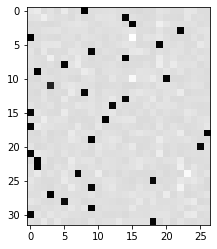

In [239]:
plt.figure(figsize=(4, 4))
plt.imshow(dlogits.detach(), cmap='gray')

## Exercise 3: BatchNorm Backward Pass (All in One Go)

Just like Exercise 2 simplified cross-entropy into one formula, here we derive the **closed-form gradient through BatchNorm** in a single expression.

### The BatchNorm forward pass:
```
hpreact = γ * (hprebn - mean) / sqrt(var + ε) + β
```

### Why BatchNorm backprop is tricky

```mermaid
graph LR
    subgraph input["hprebn (32 rows × 64 cols)"]
        direction TB
        I1["x₁ⱼ"] ~~~ I2["x₂ⱼ"] ~~~ I3["..."] ~~~ I4["x₃₂ⱼ"]
    end

    subgraph stats["Statistics for neuron j"]
        direction TB
        M["mean_j = avg(all 32)"]
        V["var_j = var(all 32)"]
    end

    subgraph output["hpreact (32 rows × 64 cols)"]
        direction TB
        O1["y₁ⱼ"] ~~~ O2["y₂ⱼ"] ~~~ O3["..."] ~~~ O4["y₃₂ⱼ"]
    end

    I1 & I2 & I3 & I4 --> M & V
    M & V --> O1 & O2 & O3 & O4

    style stats fill:#ff9,stroke:#aa3
```

**The problem:** Changing ANY input `xᵢⱼ` shifts the mean AND variance, which changes the output for ALL 32 examples. So the gradient of one output flows back to **all** inputs.

### The three gradient paths:

```mermaid
graph TD
    dhpreact["dhpreact (given)"]

    dhpreact --> P1["PATH 1: Direct\nn · dhpreact"]
    dhpreact --> P2["PATH 2: Through mean\n- dhpreact.sum(0)"]
    dhpreact --> P3["PATH 3: Through variance\n- n/(n-1) · bnraw · (dhpreact·bnraw).sum(0)"]

    P1 --> SUM["➕ Sum all three paths"]
    P2 --> SUM
    P3 --> SUM

    SUM --> result["dhprebn = γ · σ⁻¹ / n · (sum)"]

    style P1 fill:#adf,stroke:#48a
    style P2 fill:#fda,stroke:#a84
    style P3 fill:#daf,stroke:#84a
    style SUM fill:#afa,stroke:#3a3
    style result fill:#afa,stroke:#3a3
```

| Path | Term | Intuition |
|------|------|-----------|
| 🔵 **Direct** | `n · dhpreact` | As if mean and var were constants |
| 🟠 **Mean** | `- dhpreact.sum(0)` | Gradient leaks to all examples via the shared mean |
| 🟣 **Variance** | `- n/(n-1) · bnraw · (dhpreact·bnraw).sum(0)` | Gradient flows through the shared variance (Bessel's correction gives `n/(n-1)`) |

### The combined formula:
```python
dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
```

*This is mathematically equivalent to the step-by-step backprop in Exercise 1, just algebraically simplified into one expression.*

In [269]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out

# forward pass

# before (7 separate steps):
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now (one expression replaces all 7 steps):
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max()) # should be ~0

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [279]:
# backward pass: the closed-form gradient of batchnorm w.r.t. its input

# before (9 separate steps):
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# now (one expression combining all three gradient paths):
dhprebn = bngain*bnvar_inv/n * ( # common factor: gamma / (std * n)
    n*dhpreact # term 1: direct path (as if mean/var were constants)
    - dhpreact.sum(0) # term 2: gradient through the mean subtraction
    - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0) # term 3: gradient through the variance (Bessel's n/(n-1))
)

cmp('hprebn', dhprebn, hprebn) # approximate match (maxdiff ~9e-10)

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


In [278]:
dhprebn.shape, bngain.shape, bnvar_inv.shape, dbnraw.shape, dbnraw.sum(0).shape

(torch.Size([32, 64]),
 torch.Size([1, 64]),
 torch.Size([1, 64]),
 torch.Size([32, 64]),
 torch.Size([64]))

## Exercise 4: Putting It All Together — Full Manual Training Loop

Now we combine all the manual backward passes into a complete training loop.

### The full backward pass with shortcuts:

```mermaid
graph TD
    loss["🔴 loss"]

    loss --> CE["Exercise 2 Shortcut\ndlogits = softmax - one_hot / n"]

    CE --> dh["dh = dlogits @ W2.T"]
    CE --> dW2["dW2 = h.T @ dlogits ✏️"]
    CE --> db2["db2 = dlogits.sum(0) ✏️"]

    dh --> tanh["tanh backward\ndhpreact = (1-h²) · dh"]

    tanh --> dbngain["dbngain ✏️"]
    tanh --> dbnbias["dbnbias ✏️"]
    tanh --> BN["Exercise 3 Shortcut\ndhprebn = γ·σ⁻¹/n · (3 terms)"]

    BN --> dembcat["dembcat = dhprebn @ W1.T"]
    BN --> dW1["dW1 = embcat.T @ dhprebn ✏️"]
    BN --> db1["db1 = dhprebn.sum(0) ✏️"]

    dembcat --> demb["demb = dembcat.view(...)"]
    demb --> dC["dC: scatter-add loop ✏️"]

    style loss fill:#f66,stroke:#333,color:#fff
    style CE fill:#e8f4e8,stroke:#4a4,stroke-width:2px
    style BN fill:#e8f4e8,stroke:#4a4,stroke-width:2px
    style dW2 fill:#afa,stroke:#3a3
    style db2 fill:#afa,stroke:#3a3
    style dbngain fill:#afa,stroke:#3a3
    style dbnbias fill:#afa,stroke:#3a3
    style dW1 fill:#afa,stroke:#3a3
    style db1 fill:#afa,stroke:#3a3
    style dC fill:#afa,stroke:#3a3
```

**Legend:** Green ✏️ = learnable parameter gradients (collected into `grads` list) | Green boxes = shortcut formulas from exercises 2 & 3

### Key insight: `torch.no_grad()`
Since we compute every gradient manually, PyTorch doesn't need to build a computation graph at all. Wrapping everything in `torch.no_grad()` skips graph construction, making training **faster and more memory-efficient**.

### "Cheems doge" vs "swole doge":
- **Cheems doge** (before): `loss.backward()` then `p.data += -lr * p.grad`
- **Swole doge** (now): Manually computed `grads` list, then `p.data += -lr * grad`

Same result, but now you understand every single gradient that flows through the network!

In [286]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) # Kaiming init
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1 # small init: avoid confident wrong predictions
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0 # gamma, ~1.0
bnbias = torch.randn((1, n_hidden))*0.1 # beta, ~0.0

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# torch.no_grad() = no autograd overhead since we compute gradients manually
with torch.no_grad():

  # kick off optimization
  for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # (32,3,10): embed characters
    embcat = emb.view(emb.shape[0], -1) # (32,30): concatenate embeddings
    hprebn = embcat @ W1 + b1 # (32,200): linear layer 1
    # BatchNorm layer
    bnmean = hprebn.mean(0, keepdim=True) # (1,200): batch mean per neuron
    bnvar = hprebn.var(0, keepdim=True, unbiased=True) # (1,200): batch variance per neuron
    bnvar_inv = (bnvar + 1e-5)**-0.5 # (1,200): inverse std
    bnraw = (hprebn - bnmean) * bnvar_inv # (32,200): normalized activations
    hpreact = bngain * bnraw + bnbias # (32,200): scale and shift
    h = torch.tanh(hpreact) # (32,200): non-linearity
    logits = h @ W2 + b2 # (32,27): output scores
    loss = F.cross_entropy(logits, Yb) # scalar: loss

    # backward pass
    for p in parameters:
      p.grad = None

    # manual backprop! #swole_doge_meme
    # ----- cross-entropy backward (Exercise 2 shortcut) -----
    dlogits = F.softmax(logits, 1) # softmax probs
    dlogits[range(n), Yb] -= 1 # subtract 1 at correct class
    dlogits /= n # average over batch
    # ----- linear layer 2 backward -----
    dh = dlogits @ W2.T # grad through W2 to hidden layer
    dW2 = h.T @ dlogits # grad for W2
    db2 = dlogits.sum(0) # grad for b2 (sum over batch)
    # ----- tanh backward -----
    dhpreact = (1.0 - h**2) * dh # tanh derivative: 1 - tanh^2
    # ----- batchnorm backward (Exercise 3 shortcut) -----
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True) # grad for gamma
    dbnbias = dhpreact.sum(0, keepdim=True) # grad for beta
    dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0)) # full BN backward
    # ----- linear layer 1 backward -----
    dembcat = dhprebn @ W1.T # grad through W1 to embeddings
    dW1 = embcat.T @ dhprebn # grad for W1
    db1 = dhprebn.sum(0) # grad for b1
    # ----- embedding backward -----
    demb = dembcat.view(emb.shape) # reshape back to (32,3,10)
    dC = torch.zeros_like(C) # accumulate embedding gradients
    for k in range(Xb.shape[0]): # loop over batch
      for j in range(Xb.shape[1]): # loop over context positions
        ix = Xb[k,j]
        dC[ix] += demb[k,j] # scatter-add gradient to correct embedding row
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]

    # update: nudge each param down its gradient
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p, grad in zip(parameters, grads):
      p.data += -lr * grad # gradient descent step using our manual gradients

    # track stats
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

  #   if i >= 100: # TODO: delete early breaking when you're ready to train the full net
  #     break

12297
      0/ 200000: 3.7805
  10000/ 200000: 2.1775
  20000/ 200000: 2.3957
  30000/ 200000: 2.5032
  40000/ 200000: 2.0065
  50000/ 200000: 2.3873
  60000/ 200000: 2.3378
  70000/ 200000: 2.0640
  80000/ 200000: 2.3497
  90000/ 200000: 2.1093
 100000/ 200000: 1.9132
 110000/ 200000: 2.2229
 120000/ 200000: 1.9912
 130000/ 200000: 2.4441
 140000/ 200000: 2.3198
 150000/ 200000: 2.1857
 160000/ 200000: 2.0296
 170000/ 200000: 1.8391
 180000/ 200000: 2.0436
 190000/ 200000: 1.9200


## Verifying Gradients (Optional)

Uncomment this cell to compare manual gradients against PyTorch's autograd — useful for debugging if the training loop produces unexpected results.

In [285]:
# useful for checking your gradients
# for p,g in zip(parameters, grads):
#   cmp(str(tuple(p.shape)), g, p)

## Calibration, Evaluation, and Sampling

Same as Part 3:
1. **Calibrate BatchNorm** — compute exact mean/var over the full training set
2. **Evaluate** — compute loss on train and val splits using the calibrated BN statistics
3. **Sample** — generate new names from the trained model

The expected results are similar to Part 3 (train ~2.07, val ~2.12) — we're training the same model, just with manual backprop instead of autograd.

In [299]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)


In [300]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.070523500442505
val 2.109893560409546


In [294]:
# I achieved:
# train 2.0718822479248047
# val 2.1162495613098145

In [301]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # ------------
      # forward pass:
      # Embedding
      emb = C[torch.tensor([context])] # (1,block_size,d)      
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # ------------
      # Sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmahzamille.
khi.
mreigeet.
khalaysie.
mahnen.
delynn.
jareen.
nellara.
chaiiv.
kaleigh.
ham.
joce.
quinn.
shoison.
jadiquintero.
dearyxi.
jace.
pinsley.
dae.
iia.
